In [1]:
import numpy as np
import os
import globals as gl
import pickle
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
import seaborn as sns
from Plot import make_yref, set_spines_and_ticks_width, save_figure_incremental
from Plot import plot_force_aligned, annotate_finger_labels,auto_margin
plt.style.use('default')
plt.style.use('dark_background')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


Figure saved to: /cifs/diedrichsen/data/SensoriMotorPrediction/figures/force_response.svg


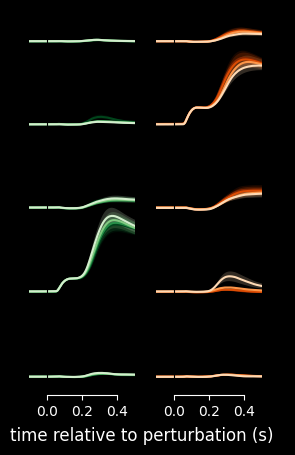

In [32]:
# === Load data ===
experiment = 'smp2'
npz = np.load(os.path.join(gl.baseDir, experiment, gl.behavDir, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

force = force[descr.GoNogo == 'go']
descr = descr[descr.GoNogo == 'go']

fig, axs = plt.subplots(1, 2, figsize=(3, 5), sharey=True, sharex=True)

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for f, finger in enumerate(descr.finger.unique()):
    for stimFinger in descr.stimFinger.unique():
        for cue in descr.cue.unique():
            force_tmp = force[(descr.cue == cue) & (descr.stimFinger == stimFinger) & (descr.finger == finger)]

            if stimFinger == 'index':
                ax=axs[0]
            else:
                ax=axs[1]

            y = force_tmp.mean(axis=0) + f * 15
            yerr = force_tmp.std(axis=0) / np.sqrt(force_tmp.shape[0])

            if ~np.isnan(y).any():
                ax.plot(tAx, y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx, y - yerr, y + yerr, color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)
# # === Initialize figure ===
# fig, axs = plt.subplots(ncols=3, figsize=(8, 5))
# vsep_go, vsep_nogo = 15, 1.5
#
# colors_go = list(gl.colour_mapping.values())[5:10]
# colors_nogo = list(gl.colour_mapping.values())[0:5]
#
# # === Plotting ===
# plot_force_aligned(force, descr, 'go', vsep_go, axs)
# plot_force_aligned(force, descr,'nogo', vsep_nogo, axs)
# annotate_finger_labels(force, descr, axs[0], vsep_nogo)
#
# # === Titles and intervals ===
# for sf, stimF in enumerate(descr.stimFinger.unique()):
#     axs[sf].set_title(f'{stimF} perturbation' if stimF != 'nogo' else 'nogo trials')
#
# axs[0].axvspan(-1.5, 0, color='grey', alpha=.3, lw=0)
# axs[1].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
# axs[2].axvspan(.2, .4, color='grey', alpha=.3, lw=0)
#
axs[0].set_xlim([-.1, .5])
axs[1].set_xlim([-.1, .5])
# axs[2].set_xlim([-.1, .5])
#
# axs[0].set_ylim([-.21, 6.90])
# axs[1].set_ylim(auto_margin(axs[1].lines))
# axs[2].set_ylim(auto_margin(axs[2].lines))
#
# axs[0].set_xticks([-1.5, 0, .4])
axs[0].set_xticks([0, .2, .4])
axs[1].set_xticks([0, .2, .4])
#
make_yref(axs[1], reference_length=5, pos='right')
# make_yref(axs[0], reference_length=.5, pos='left')
#
# axs[0].spines[['bottom']].set_bounds(-1.5, .4)
axs[0].spines[['bottom']].set_bounds(0, .4)
axs[1].spines[['bottom']].set_bounds(0, .4)

# === Styling ===
for ax in axs:
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes='x', which='both')
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])
#
# # === Title and labels ===
# fig.suptitle('Force response to finger perturbation')
fig.supxlabel('time relative to perturbation (s)')
#
# # === Save and show ===
save_figure_incremental(fig, 'force_response')
# plt.show()

/tmp/ipykernel_731812/2023009575.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_731812/2023009575.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


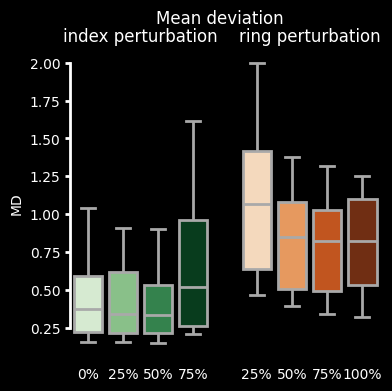

In [37]:
snS = ['102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113']
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df, df_tmp])

df.stimFinger = df.stimFinger.map(gl.stimFinger_mapping)
df.cue = df.cue.map(gl.cue_mapping)

df = df.groupby(['cue', 'stimFinger', 'sn']).mean(numeric_only=True).reset_index()
df = df[(df.stimFinger=='index') | (df.stimFinger=='ring')]

# Define a palette dictionary for each stimFinger
palette_dict = {
    'index': (list(gl.colour_mapping.values())[5:9], ['0%', '25%', '50%', '75%']),
    'ring': (list(gl.colour_mapping.values())[9:13], ['25%', '50%', '75%', '100%'])
}

fig, axs = plt.subplots(1, len(df.stimFinger.unique()), figsize=(4, 4), sharey=True)

for ax, (finger, subdf) in zip(axs, df.groupby('stimFinger')):
    sns.boxplot(
        data=subdf, x='cue', y='MD', order=palette_dict[finger][1],
        palette=palette_dict[finger][0], ax=ax, showfliers=False, legend=False, linewidth=2,linecolor='darkgray'
    )
    ax.set_title(f'{finger} perturbation')
    ax.set_xlabel('')
    # ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
    ax.tick_params(axis='y', width=0)
    ax.tick_params(axis='x', width=0)
    if ax==axs[0]:
        ax.spines[['left']].set_visible(True)
        ax.spines[['left']].set_bounds(.25, 2)
        ax.spines[['left']].set_linewidth(2)
        ax.tick_params(axis='y', width=2)


fig.suptitle('Mean deviation')

plt.show()

/tmp/ipykernel_374358/1346613306.py:25: RuntimeWarning: Mean of empty slice
  y = np.nanmean(data[:, c, s], axis=0) + ch * 6
/home/UWO/memanue5/Documents/GitHub/sensori-motor-prediction/venv/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


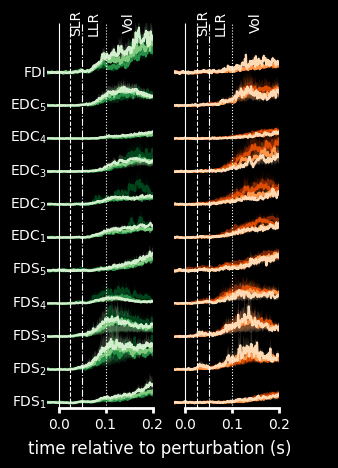

In [19]:
experiment = 'smp0'
latency = [.046, .06]

f = open(os.path.join(gl.baseDir, experiment, 'emg', 'emg.p'), 'rb')
Dict = pickle.load(f)

# Time axis for each latency
tAx = [np.linspace(-1, 2, 6444) - l for l in latency]

# Set up plot
fig, axs = plt.subplots(1, 2, sharey=True, sharex=True, figsize=(3, 5))

# Vertical lines and associated styles
line_xs = [0, .025, .05, .1]
line_styles = ['-', '--', '-.', ':']
line_labels = ['SLR', 'LLR', 'Vol']

for ch, channel in enumerate(Dict.keys()):
    for c, cue in enumerate(gl.cues[::-1]):
        for s, stimFinger in enumerate(gl.stimFinger):

            ax = axs[s]

            data = np.array(Dict[channel])
            y = np.nanmean(data[:, c, s], axis=0) + ch * 6
            yerr = np.nanstd(data[:, c, s], axis=0) / np.sqrt(10)

            if ~np.isnan(y).any():
                ax.plot(tAx[s], y, color=gl.colour_mapping[f'{cue},{stimFinger}'])
                ax.fill_between(tAx[s], y- yerr, y + yerr,
                                color=gl.colour_mapping[f'{cue},{stimFinger}'], lw=0, alpha=.2)

            if (s == 0) & (c == 1):
                label = (f'FDS$_{{{ch+1}}}$' if ch < 5 else
                         f'EDC$_{{{ch-4}}}$' if (ch >= 5) & (ch < 10) else
                         'FDI' if ch == 10 else '')
                ax.text(-.025, y[0], label, va='center', ha='right',)

# Draw vertical lines
for ax in axs:
    ax.set_ylim((0, 70))
    for x, style in zip(line_xs, line_styles):
        ax.vlines(x, ymin=0, ymax=ax.get_ylim()[1], linestyles=style, color='w', lw=.8)

    ax.set_xlim([-.025, .2])

#     ax.set_ylim([0, 1.15])
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_visible(True)

    # Remove y-ticks and labels
    ax.set_yticks([])
    ax.set_yticklabels([])

    ax.spines['bottom'].set_bounds([0, .2])
    ax.spines['bottom'].set_linewidth(2)
    ax.tick_params(width=2)
    ax.set_xticks([0, .1, .2])
    # set_spines_and_ticks_width(ax, spine_width=1.5, spine_sides=('bottom',), tick_width=1.5, axes=('x',), which='both')

    # Place text labels between key vertical lines
    xlims = ax.get_xlim()
    text_positions = [
        (.025 + .05) / 2,          # "SLR"
        (.05 + .1) / 2,            # "LLR"
        (.1 + xlims[1]) / 2        # "Vol"
    ]
    for label, xpos in zip(line_labels, text_positions):
        ax.text(xpos, ax.get_ylim()[1], label, ha='center', va='center',  rotation=90,)
#
# # Global labels and layout
fig.supxlabel('time relative to perturbation (s)')
# fig.suptitle('EMG response to finger perturbation')
#
make_yref(axs[1], reference_length=.1, pos='right', unit='mV')

plt.show()
